<a href="https://colab.research.google.com/github/Ayushgautam75/LIVE-PW-ML/blob/main/LINEAR_REGRESSION_Machine_Learning_02_Live.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



In [51]:
df=pd.read_csv("plant.csv")

In [52]:
df

,Pesticide_Amount_mg_per_ha,Plant_Production
0,0,10
1,50,15
2,100,18
3,150,20
4,200,21
5,250,20
6,300,18
7,350,15
8,400,10
9,450,4


Text(0, 0.5, 'Plant_Production')

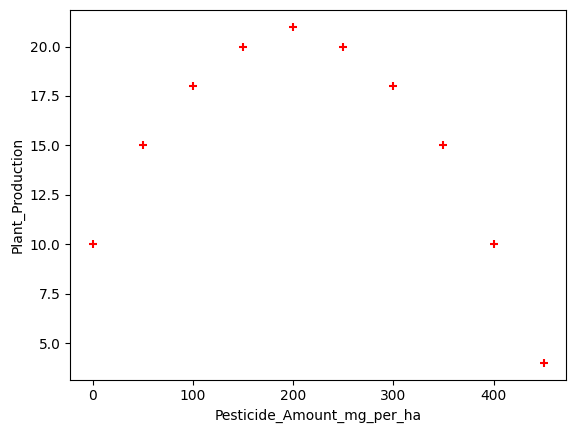

In [53]:
plt.scatter(df['Pesticide_Amount_mg_per_ha'], df['Plant_Production'], color = 'red', marker = '+')
plt.xlabel('Pesticide_Amount_mg_per_ha')
plt.ylabel('Plant_Production')

In [54]:
line = LinearRegression()
line.fit(df[['Pesticide_Amount_mg_per_ha']], df['Plant_Production'])

LinearRegression()

Text(0, 0.5, 'Plant_Production')

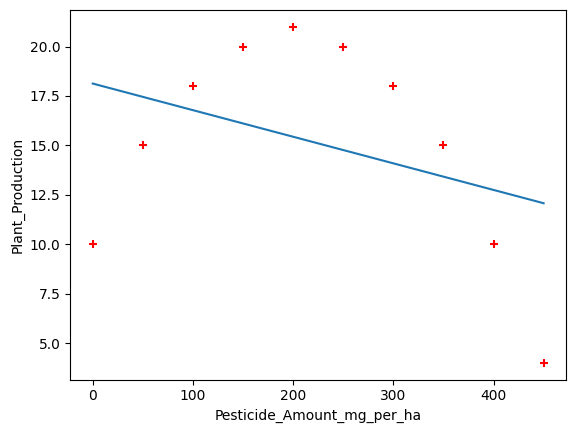

In [55]:
plt.scatter(df['Pesticide_Amount_mg_per_ha'], df['Plant_Production'], color = 'red', marker = '+')
plt.plot(df['Pesticide_Amount_mg_per_ha'], line.predict(df[['Pesticide_Amount_mg_per_ha']]))
plt.xlabel('Pesticide_Amount_mg_per_ha')
plt.ylabel('Plant_Production')

In [56]:
#quadratic regression
from sklearn.preprocessing import PolynomialFeatures

In [57]:
squaringFunction = PolynomialFeatures(degree = 2)
pesticide_square = squaringFunction.fit_transform(df[['Pesticide_Amount_mg_per_ha']])

In [58]:
pesticide_square

array([[1.000e+00, 0.000e+00, 0.000e+00],
       [1.000e+00, 5.000e+01, 2.500e+03],
       [1.000e+00, 1.000e+02, 1.000e+04],
       [1.000e+00, 1.500e+02, 2.250e+04],
       [1.000e+00, 2.000e+02, 4.000e+04],
       [1.000e+00, 2.500e+02, 6.250e+04],
       [1.000e+00, 3.000e+02, 9.000e+04],
       [1.000e+00, 3.500e+02, 1.225e+05],
       [1.000e+00, 4.000e+02, 1.600e+05],
       [1.000e+00, 4.500e+02, 2.025e+05]])

In [59]:
parabola = LinearRegression()
parabola.fit(pesticide_square, df['Plant_Production'])

LinearRegression()

Text(0, 0.5, 'Plant_Production')

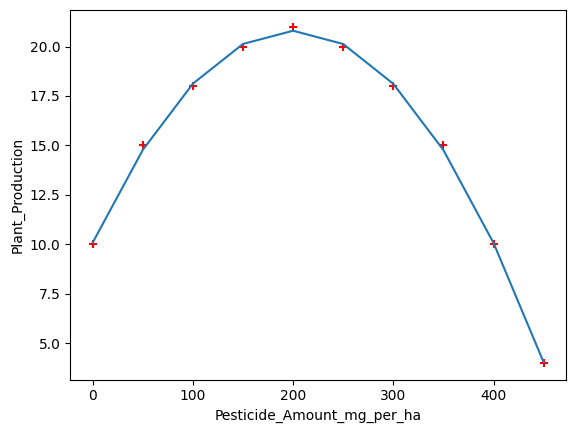

In [60]:
plt.scatter(df['Pesticide_Amount_mg_per_ha'], df['Plant_Production'], color = 'red', marker = '+')
plt.plot(df['Pesticide_Amount_mg_per_ha'],parabola.predict(pesticide_square) )
plt.xlabel('Pesticide_Amount_mg_per_ha')
plt.ylabel('Plant_Production')

In [61]:
parabola.coef_

array([ 0.        ,  0.10722727, -0.00026818])

In [62]:
parabola.predict(pesticide_square)

array([10.08181818, 14.77272727, 18.12272727, 20.13181818, 20.8       ,
       20.12727273, 18.11363636, 14.75909091, 10.06363636,  4.02727273])

In [63]:
parabola.intercept_

np.float64(10.081818181816287)

# **Project 2**

In [64]:
df=pd.read_csv("/content/house_pricing.csv")

In [65]:
df

,size_sqft,bedrooms,price
0,1200.0,2.0,180000
1,1500.0,3.0,250000
2,1800.0,3.0,290000
3,2000.0,4.0,320000
4,2200.0,4.0,380000
5,1600.0,3.0,240000
6,2500.0,5.0,420000
7,1400.0,NaN,210000
8,3000.0,5.0,550000
9,1700.0,3.0,260000


In [66]:
df['size_sqft'] = df['size_sqft'].fillna(df['size_sqft'].median())
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [68]:
df

,size_sqft,bedrooms,price
0,1200.0,2.0,180000
1,1500.0,3.0,250000
2,1800.0,3.0,290000
3,2000.0,4.0,320000
4,2200.0,4.0,380000
5,1600.0,3.0,240000
6,2500.0,5.0,420000
7,1400.0,3.5,210000
8,3000.0,5.0,550000
9,1700.0,3.0,260000


In [88]:
num_cols = df.select_dtypes(include = np.number).columns
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 *IQR
  upper = Q3 + 1.5 *IQR
  df = df[(df[col]>=lower)& (df[col]<= upper)] #outlier remove


In [74]:
X = df.drop(columns = ['price'])
y = df['price']

In [75]:
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42)


In [76]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [77]:
y_pred = model.predict(X_test)

In [87]:
r2_score_value = r2_score(y_test, y_pred)
print(f"R-squared: {r2_score_value*100:.4f}")
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse*100:.4f}")
print(f"Mean Absolute Error (MAE): {mae*100:.4f}")


R-squared: 98.1230
Root Mean Squared Error (RMSE): 1008824.5833
Mean Absolute Error (MAE): 965319.5462


In [90]:
plt.show()

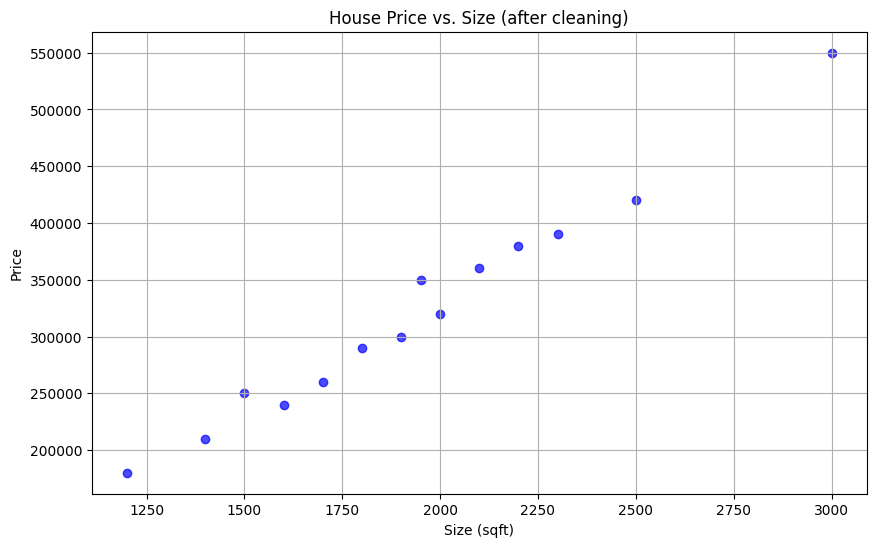

In [91]:
plt.figure(figsize=(10, 6))
plt.scatter(df['size_sqft'], df['price'], color='blue', alpha=0.7)
plt.xlabel('Size (sqft)')
plt.ylabel('Price')
plt.title('House Price vs. Size (after cleaning)')
plt.grid(True)
plt.show()